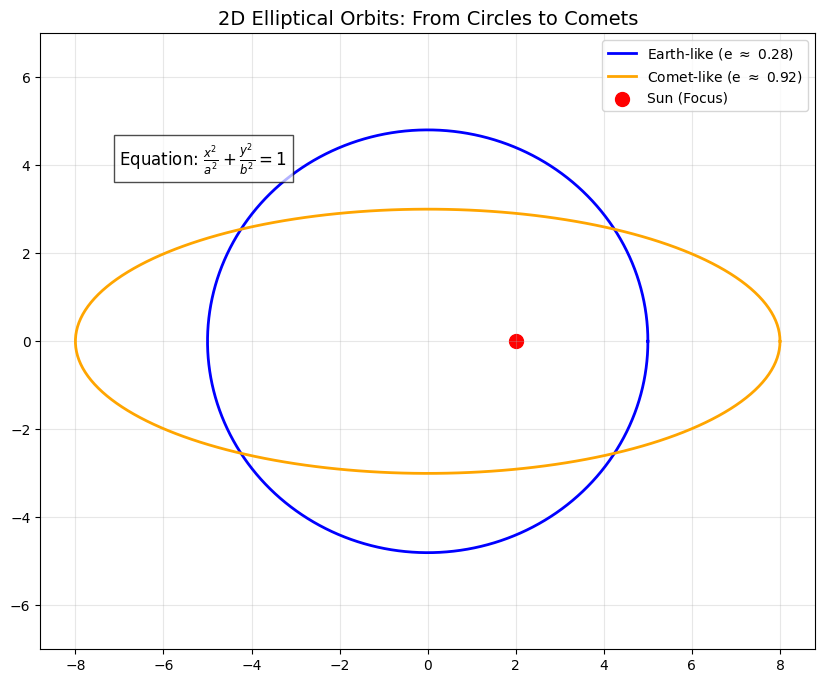

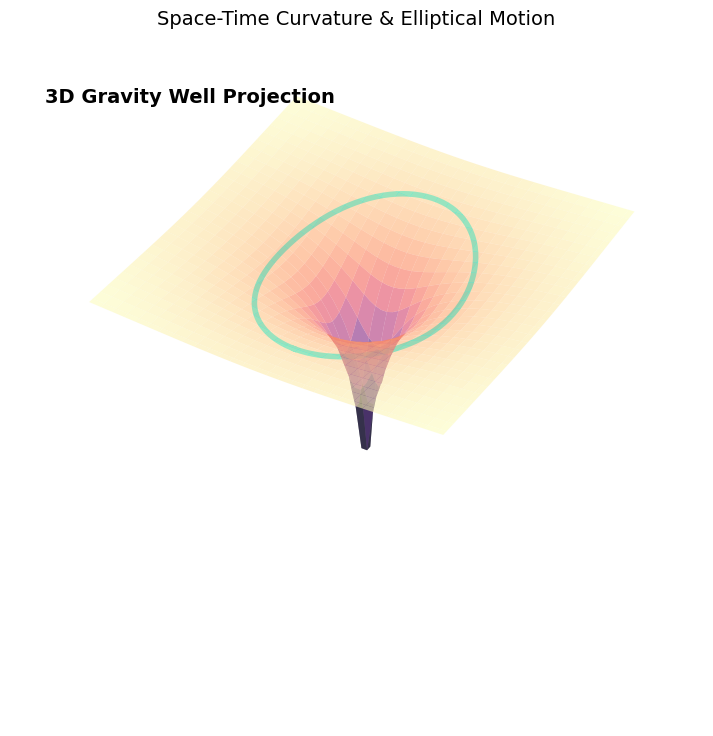

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def run_ellipse_master():
    # --- PROFESSIONAL PATH SETUP ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path): os.makedirs(asset_path)

    # 1. Generate Ellipse Data
    theta = np.linspace(0, 2*np.pi, 200)
    
    def get_ellipse(a, b):
        x = a * np.cos(theta)
        y = b * np.sin(theta)
        return x, y

    # --- 📸 ASSET 1: ECCENTRICITY COMPARISON (64_ellipse_2d.png) ---
    plt.figure(figsize=(10, 8))
    
    # Earth-like (Low eccentricity)
    x1, y1 = get_ellipse(5, 4.8)
    plt.plot(x1, y1, label=r"Earth-like (e $\approx$ 0.28)", color='blue', lw=2)
    
    # Comet-like (High eccentricity)
    x2, y2 = get_ellipse(8, 3)
    plt.plot(x2, y2, label=r"Comet-like (e $\approx$ 0.92)", color='orange', lw=2)
    
    # Plot Focus (The Sun)
    plt.scatter([2], [0], color='red', s=100, label="Sun (Focus)")
    
    plt.text(-7, 4, r"Equation: $\frac{x^2}{a^2} + \frac{y^2}{b^2} = 1$", fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
    plt.title("2D Elliptical Orbits: From Circles to Comets", fontsize=14)
    plt.axis('equal'); plt.grid(alpha=0.3); plt.legend()
    
    plt.savefig(os.path.join(asset_path, '64_ellipse_2d.png'), dpi=300)
    plt.show()

    # --- 📸 ASSET 2: GRAVITY WELL SURFACE (64_ellipse_3d.png) ---
    fig = plt.figure(figsize=(12, 9))
    ax3d = fig.add_subplot(111, projection='3d')
    
    # Create a Gravity Well: Potential V = -1 / sqrt(x^2 + y^2)
    x_range = np.linspace(-5, 5, 60)
    y_range = np.linspace(-5, 5, 60)
    X, Y = np.meshgrid(x_range, y_range)
    R = np.sqrt(X**2 + Y**2) + 0.5 # Add 0.5 to avoid singularity at center
    Z = -5 / R 

    surf = ax3d.plot_surface(X, Y, Z, cmap='magma', alpha=0.6, edgecolor='none')
    
    # Plot an elliptical path on this surface
    xe, ye = get_ellipse(3.5, 2.5)
    ze = -5 / (np.sqrt(xe**2 + ye**2) + 0.5)
    ax3d.plot(xe, ye, ze, color='cyan', lw=4, label='Planetary Path')

    ax3d.text2D(0.05, 0.9, "3D Gravity Well Projection", transform=ax3d.transAxes, fontsize=14, weight='bold')
    ax3d.set_title("Space-Time Curvature & Elliptical Motion", fontsize=14)
    ax3d.set_zlim(-10, 0)
    ax3d.axis('off') # Hide axes for a more 'space' feel
    
    ax3d.view_init(elev=40, azim=30)
    plt.savefig(os.path.join(asset_path, '64_ellipse_3d.png'), dpi=300)
    plt.show()

if __name__ == "__main__":
    run_ellipse_master()